In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
data = fetch_california_housing()

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)

In [4]:
df["price"] = data.target

In [5]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
regressor = LinearRegression()

regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = regressor.predict(X_test)

In [10]:
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R2 Score: 0.5943232652466204
MAE: 0.5351261336554506
MSE: 0.5289841670367208
RMSE: 0.7273129773603114


In [11]:
print("\nFeature Coefficients:")

for name, coef in zip(data.feature_names, regressor.coef_):
    print(name, ":", coef)


Feature Coefficients:
MedInc : 0.8262479345502426
HouseAge : 0.11710060171636005
AveRooms : -0.2489105895216479
AveBedrms : 0.29038745593181053
Population : -0.0086434931074905
AveOccup : -0.030564285818427826
Latitude : -0.9004211189838728
Longitude : -0.8705856576043259


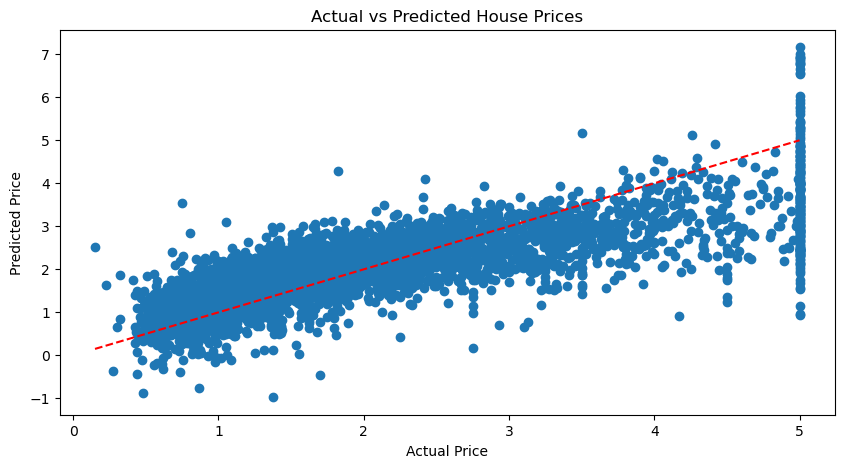

In [12]:
plt.figure(figsize=(10,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.show()